In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load dataset
data_path = r"C:\visual_searh_project\data\raw_data\Stanford_Online_Products\Stanford_Online_Products"

total = 0
for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith('.jpg') or f.lower().endswith('.jpeg') or f.lower().endswith('.png'):
            total += 1

print(f"Total images: {total}")

Total images: 120053


In [14]:
import os

data_path = r"C:\visual_searh_project\data\raw_data\Stanford_Online_Products\Stanford_Online_Products"

# Just list what's directly inside
print(os.listdir(data_path))

['bicycle_final', 'bicycle_final.txt', 'cabinet_final', 'cabinet_final.txt', 'chair_final', 'chair_final.txt', 'coffee_maker_final', 'coffee_maker_final.txt', 'Ebay_final.txt', 'Ebay_info.txt', 'Ebay_test.txt', 'Ebay_train.txt', 'fan_final', 'fan_final.txt', 'kettle_final', 'kettle_final.txt', 'lamp_final', 'lamp_final.txt', 'LICENSE', 'mug_final', 'mug_final.txt', 'README', 'sofa_final', 'sofa_final.txt', 'stapler_final', 'stapler_final.txt', 'table_final', 'table_final.txt', 'toaster_final', 'toaster_final.txt']


Found 120053 images


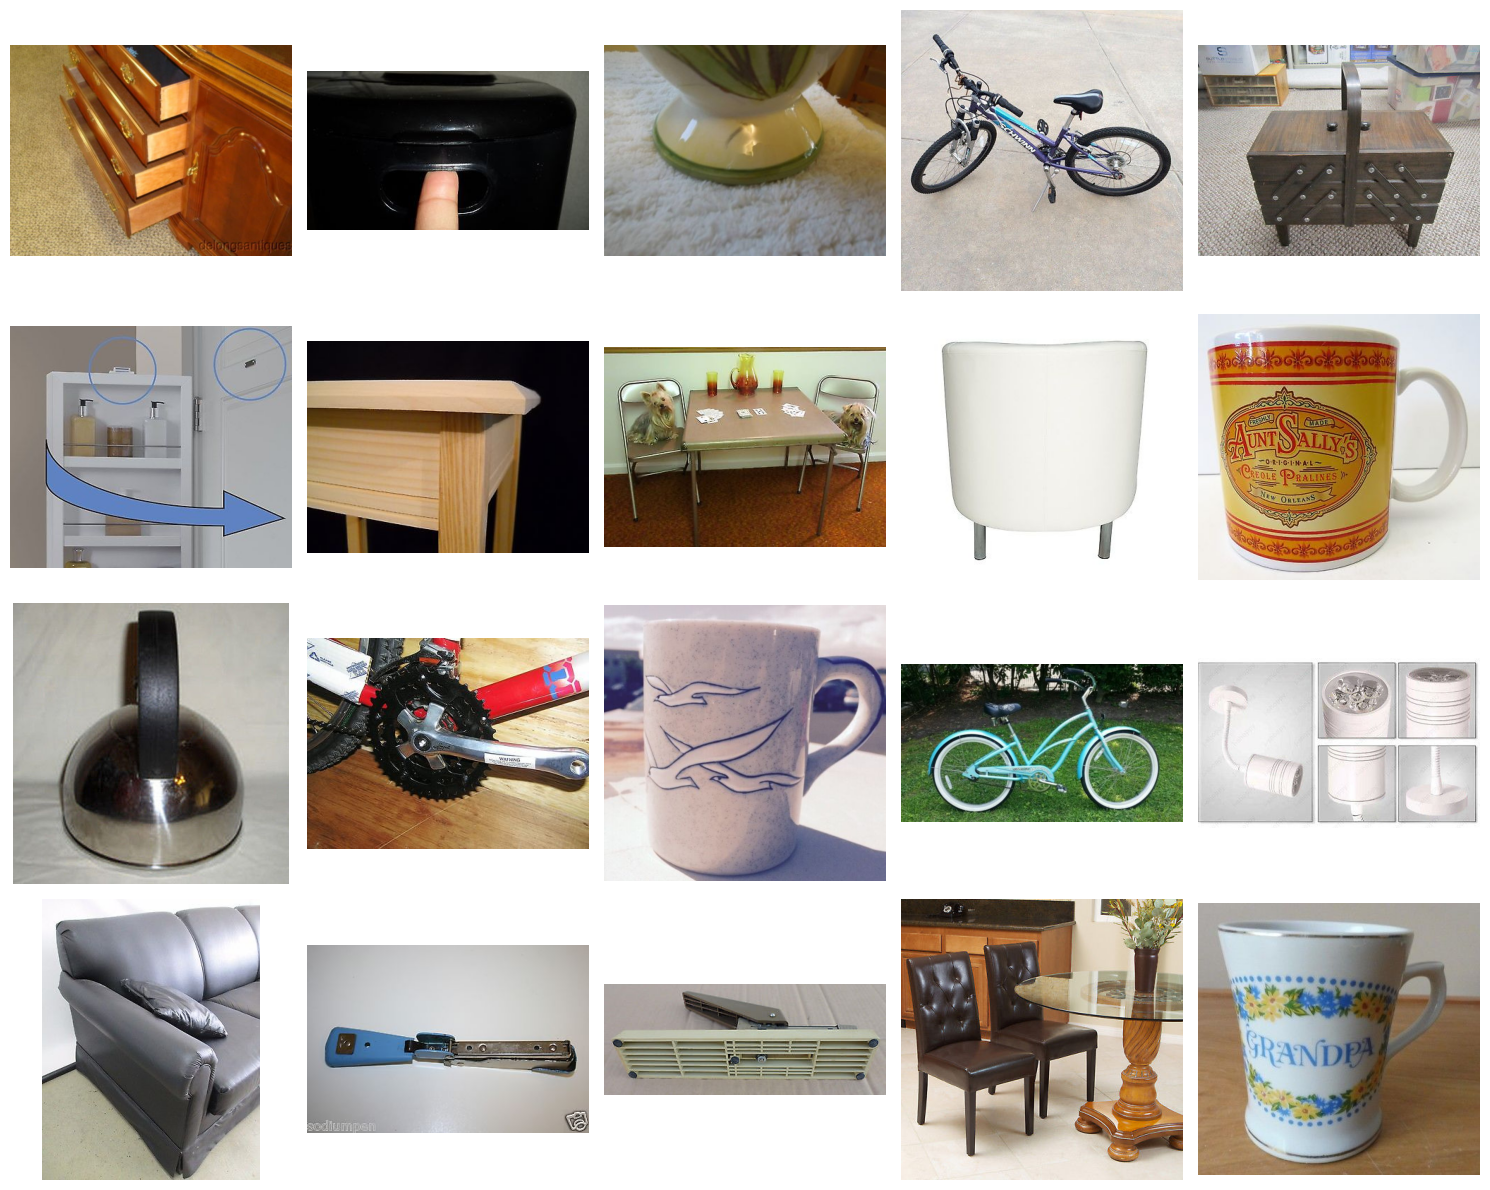

In [20]:

import random


def show_random_images(data_path, n=20):
    all_images = []
    for root, dirs, files in os.walk(data_path):
        for f in files:
            if f.lower().endswith('.jpg') or f.lower().endswith('.jpeg') or f.lower().endswith('.png'):
                all_images.append(os.path.join(root, f))
    
    print(f"Found {len(all_images)} images")  # confirm it finds images
    
    samples = random.sample(all_images, n)
    
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    for i, ax in enumerate(axes.flat):
        img = Image.open(samples[i])
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_random_images(data_path)

Total images found: 120053


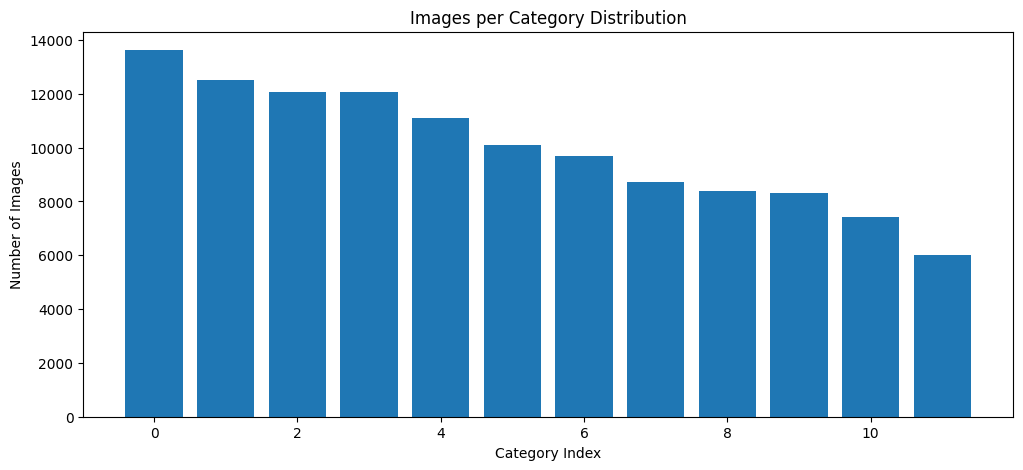

Total categories: 12
Max images in one category: 13626
Min images in one category: 5996
Average images per category: 10004.4

Average width: 395px
Average height: 368px
Min size: 181x186
Max size: 1600x1200


In [22]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Build all_images list once here
all_images = []
for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith('.jpg') or f.lower().endswith('.jpeg') or f.lower().endswith('.png'):
            all_images.append(os.path.join(root, f))

print(f"Total images found: {len(all_images)}")

# Part 3 - Category distribution
categories = {}
for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        categories[folder] = count

plt.figure(figsize=(12, 5))
plt.bar(range(len(categories)), sorted(categories.values(), reverse=True))
plt.xlabel("Category Index")
plt.ylabel("Number of Images")
plt.title("Images per Category Distribution")
plt.show()

print(f"Total categories: {len(categories)}")
print(f"Max images in one category: {max(categories.values())}")
print(f"Min images in one category: {min(categories.values())}")
print(f"Average images per category: {np.mean(list(categories.values())):.1f}")

# Part 4 - Image size analysis
sizes = []
sample_paths = random.sample(all_images, 500)

for path in sample_paths:
    img = Image.open(path)
    sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"\nAverage width: {np.mean(widths):.0f}px")
print(f"Average height: {np.mean(heights):.0f}px")
print(f"Min size: {min(widths)}x{min(heights)}")
print(f"Max size: {max(widths)}x{max(heights)}")